# Painter Optimizer
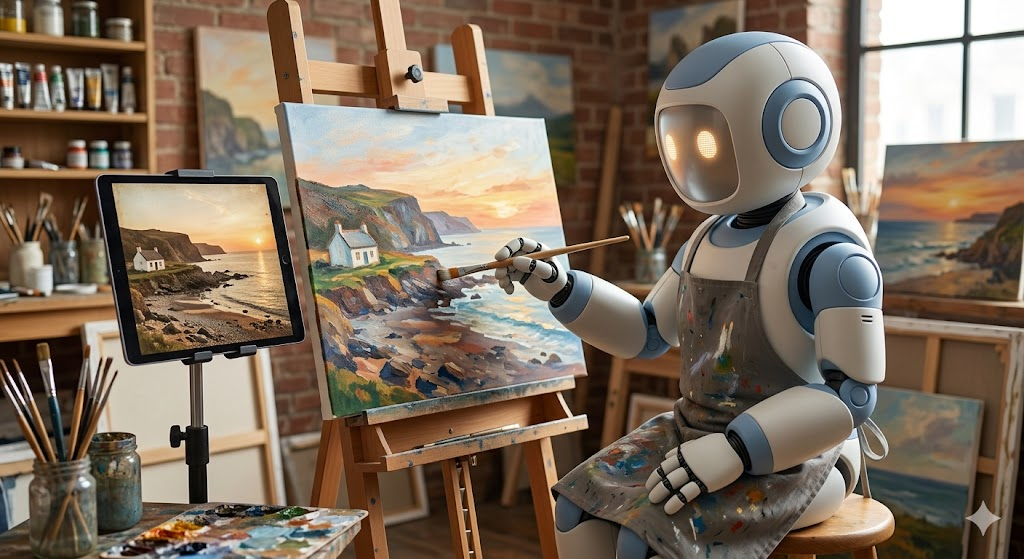

*Image generated using Nano Banana 2 (Gemini 3 PRO).*

## Introduction

Norbert is a young art student who is particularly fascinated by abstract art. As part of his latest experiment, he created a composition made of many semi-transparent colored circles overlapping each other. Fascinated by the result, Norbert began to consider the inverse problem: can we precisely reconstruct the parameters of all circles that form a given image?

Your task is to help the young painter Norbert design an algorithm that performs this decomposition and finds all the circle parameters that can be used to reconstruct the painted image.

## Task

Your main task is to implement the function `solve()` located in the `YourSolution` class.

This function should, for each image, find a set of parameters `params` describing all colored circles that form the given image.

You are provided with a function `differentiable_renderer`. It takes:

* `params` (torch.Tensor) — a tensor of shape `[N, 7]`, where `N` is the number of circles and 7 is the number of parameters per circle.
* `H` (int) — output image height.
* `W` (int) — output image width.

The function returns a PyTorch tensor of shape `[3, H, W]`, representing a color image composed of `N` overlapping circles.

The name `differentiable_renderer` is intentional. It means the rendering process is mathematically “transparent” to optimization algorithms. The exact implementation and example images are shown in the cells below.

Your goal is to find parameters `params` such that, after using `differentiable_renderer`, the resulting image is as close as possible to the original image. In other words, you must reconstruct circle parameters that best approximate the input image after rendering.

For each image, you must return exactly `N` circle parameters.

## Data

The dataset contains images generated by this function, each represented as a tensor of shape `[3, H, W]`.

Each image (both validation and test) consists of `N = 10` overlapping circles. Each circle is defined by 7 parameters:

* position_X — X coordinate of the circle
* position_Y — Y coordinate of the circle
* r — circle radius
* color_R — red channel value
* color_G — green channel value
* color_B — blue channel value
* alpha — transparency of the circle

You are provided with two datasets stored in `train_validation_sets.npz`:

* `x_train` — 50 training images `[50, 3, H, W]`
* `x_val` — 10 validation images `[10, 3, H, W]`
* `y_train` — ground truth circle parameters for training images `[50, N, 7]`
* `y_val` — ground truth circle parameters for validation images `[10, N, 7]`

Test data `x_test` and `y_test`, used for final evaluation, have shapes `[10, 3, H, W]` and `[10, N, 7]`. You do not have access to them; they are hidden on the evaluation platform.

## Evaluation Metric

Your solution quality is evaluated using **MSE (Mean Squared Error)** between pixels of the original and reconstructed images:

$$
\text{MSE} = \frac{1}{M} \sum_{i=1}^{M} (O_i - R_i)^2
$$

where (M = 3 \times H \times W), (O) is the original image, and (R) is the reconstructed image obtained as:
`R = differentiable_renderer(params, H, W)`.

Lower MSE means better reconstruction quality; **0.0** means perfect match.

You can score between 0 and 100 points. The score is linearly scaled based on the **average MSE** over the test set:

* **Average MSE ≥ 0.02**: 0 points
* **Average MSE ≤ 0.01**: 100 points
* **Between 0.01 and 0.02**: linearly scaled

Final scoring:

$$
\text{Points} =
\begin{cases}
0 & \text{if } \text{Mean MSE} \geq 0.02 \\
100 \times \frac{0.02 - \text{Mean MSE}}{0.02 - 0.01} & \text{if } 0.01 < \text{Mean MSE} < 0.02 \\
100 & \text{if } \text{Mean MSE} \leq 0.01
\end{cases}
$$

## Constraints

* The solution will run on the competition platform **without internet access and without GPU**.
* Final evaluation must not exceed **5 minutes (CPU only)**.
* Allowed libraries: `scikit-learn`, `numpy`, `pandas`, `pytorch`.
* You must return exactly `N` circles for each image.

## Submission Files

This notebook filled with your solution (see `YourSolution` class).

## Evaluation

Remember that during evaluation the flag `FINAL_EVALUATION_MODE` will be set to `True`.

You can score between 0 and 100 points. The score is computed on a hidden test set on the competition platform and rounded to an integer. If your solution does not meet the requirements or fails to run, you will receive **0 points**.


# Starter Code

In this section, we initialize the environment by importing the necessary libraries and functions. The provided code will help you efficiently work with the data and build an appropriate solution.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False # During evaluation on the grader, this flag is automatically set to True.

In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
import random
import numpy as np
import torch
import torch.nn.functional as F

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt


# Setting the seed of the pseudorandom number generator to ensure deterministic results
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


# Global image parameters and number of shapes used in the task
H, W = 64, 64
N_SHAPES = 10

## `differentiable_renderer` Function

We define our `differentiable_renderer` function.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
def differentiable_renderer(params, H, W):
    """
    Differentiably renders circles onto an image based on given parameters.

    Args:
        params (torch.Tensor): Tensor of shape [N, 7], where N is the number of circles.
                                Each row contains 7 parameters in the following order:
                                [position_X, position_Y, r, color_R, color_G, color_B, alpha]
        H (int): Output image height.
        W (int): Output image width.

    Returns:
        torch.Tensor: Rendered image as a tensor of shape [3, H, W].
    """
    sharpness = 20.0
    if params is None or params.shape[0] == 0:
        return torch.ones(3, H, W)
    N = params.shape[0]
    y_coords, x_coords = torch.meshgrid(torch.arange(H, dtype=torch.float32), torch.arange(W, dtype=torch.float32), indexing='ij')
    centers_x, centers_y = params[:, 0].view(N, 1, 1), params[:, 1].view(N, 1, 1)
    radii_sq = params[:, 2].view(N, 1, 1)**2
    colors = params[:, 3:6].view(N, 3, 1, 1)
    alphas = params[:, 6].view(N, 1, 1, 1)
    dist_sq = (x_coords - centers_x)**2 + (y_coords - centers_y)**2
    mask = torch.sigmoid((radii_sq - dist_sq) * sharpness)
    pixel_alpha = mask.unsqueeze(1) * alphas
    image = torch.ones(3, H, W)
    for i in range(N):
        image = colors[i] * pixel_alpha[i] + image * (1.0 - pixel_alpha[i])
    return image

## Data Loading

Using the code below, the data will be loaded and properly prepared.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
def setup_data_from_npz(path_to_npz: str, mode: str):

    bundle_npz = np.load(path_to_npz, allow_pickle=True)
    if mode == "train":
        x_bundle_name, y_bundle_name = "X_train", "y_train"
    elif mode == "val":
        x_bundle_name, y_bundle_name = "X_validation", "y_validation"

    x = torch.from_numpy(bundle_npz[x_bundle_name]).float()
    y = torch.from_numpy(bundle_npz[y_bundle_name]).float()

    return x, y

if not FINAL_EVALUATION_MODE:
    x_train, y_train = setup_data_from_npz("train_validation_sets.npz", "train")
    x_val, y_val = setup_data_from_npz("train_validation_sets.npz", "val")

## Data Visualization

Using the `matplotlib` library, we can display example images from the training and validation sets.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
import matplotlib.pyplot as plt

def display_sample(data_tensor, title="Przykładowy obraz"):
    """
    Displays a single image from a PyTorch tensor.
    Matplotlib expects images in [H, W, C] format, so we need to convert the tensor from [C, H, W],
    where C is the number of channels (in our case 3 - RGB), H is height, and W is width.
    """
    img = data_tensor.permute(1, 2, 0).numpy()
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


if not FINAL_EVALUATION_MODE:
    display_sample(x_train[0], title="Example image from training set")
    display_sample(x_val[0], title="Example image from validation set")

## Evaluation Code

Code similar to the one below will be used to evaluate the solution on the test set.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
def compute_score(mse: float) -> float:
    """
    - MSE <= 0.01 receives 100 points.
    - MSE >= 0.02 receives 0 points.
    - The score is linearly interpolated between these thresholds.
    """
    lower_bound_mse = 0.01
    upper_bound_mse = 0.02

    if mse <= lower_bound_mse:
        return 100.0
    if mse >= upper_bound_mse:
        return 0.0

    # Linear interpolation
    score = 100.0 * (upper_bound_mse - mse) / (upper_bound_mse - lower_bound_mse)
    return score


def evaluate_solution(solution, ds) -> float:
    """Ocenia rozwiązanie na podanym zbiorze danych."""
    total_mse = 0.0
    for i in range(ds.shape[0]):
        target_image = ds[i]

        # Run algorithm
        final_params = solution.solve(target_image.clone())
        assert final_params.shape == (N_SHAPES, 7), \
            f"Zwrócony tensor ma niepoprawny kształt: {final_params.shape}, oczekiwano ({N_SHAPES}, 7)"

        # Evaluation
        final_image = differentiable_renderer(final_params, H, W)
        mse = F.mse_loss(final_image, target_image).item()
        total_mse += mse

    average_mse = total_mse / ds.shape[0]
    return average_mse


## Your Solution

In this section, you should place your solution. Make changes only here!


In [ ]:
class YourSolution():
    def solve(self, target_image: torch.Tensor) -> torch.Tensor:
        """
        Method that, for a given target image, should run an optimization algorithm
        and return the final tensor with circle parameters.

        Args:
            target_image (torch.Tensor): Target image tensor of shape [3, H, W].

        Returns:
            torch.Tensor: Tensor with optimized circle parameters of shape [N_SHAPES, 7].
        """
        # Example solution that returns random parameters for each image
        # Remove all code below to implement your solution
        with torch.no_grad():
            params = torch.rand(N_SHAPES, 7) # Random parameter values
        return params

## Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data. Before submission, make sure that the entire notebook runs from start to finish without errors and without requiring any user interaction after selecting the **"Run All"** option.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
if not FINAL_EVALUATION_MODE:
    your_solution = YourSolution()
    mse = evaluate_solution(your_solution, x_val)
    score = compute_score(mse)
    print("Evaluation of YourSolution on validation set:")
    print(f"Mean Squared Error (MSE): {mse: .6f}")
    print(f"Score: {score} pts")